In [2]:
from scipy.signal import firwin, remez, firls, freqz
from scipy.signal import lfilter, filtfilt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Diseño de Filtros FIR usando PyFDAx

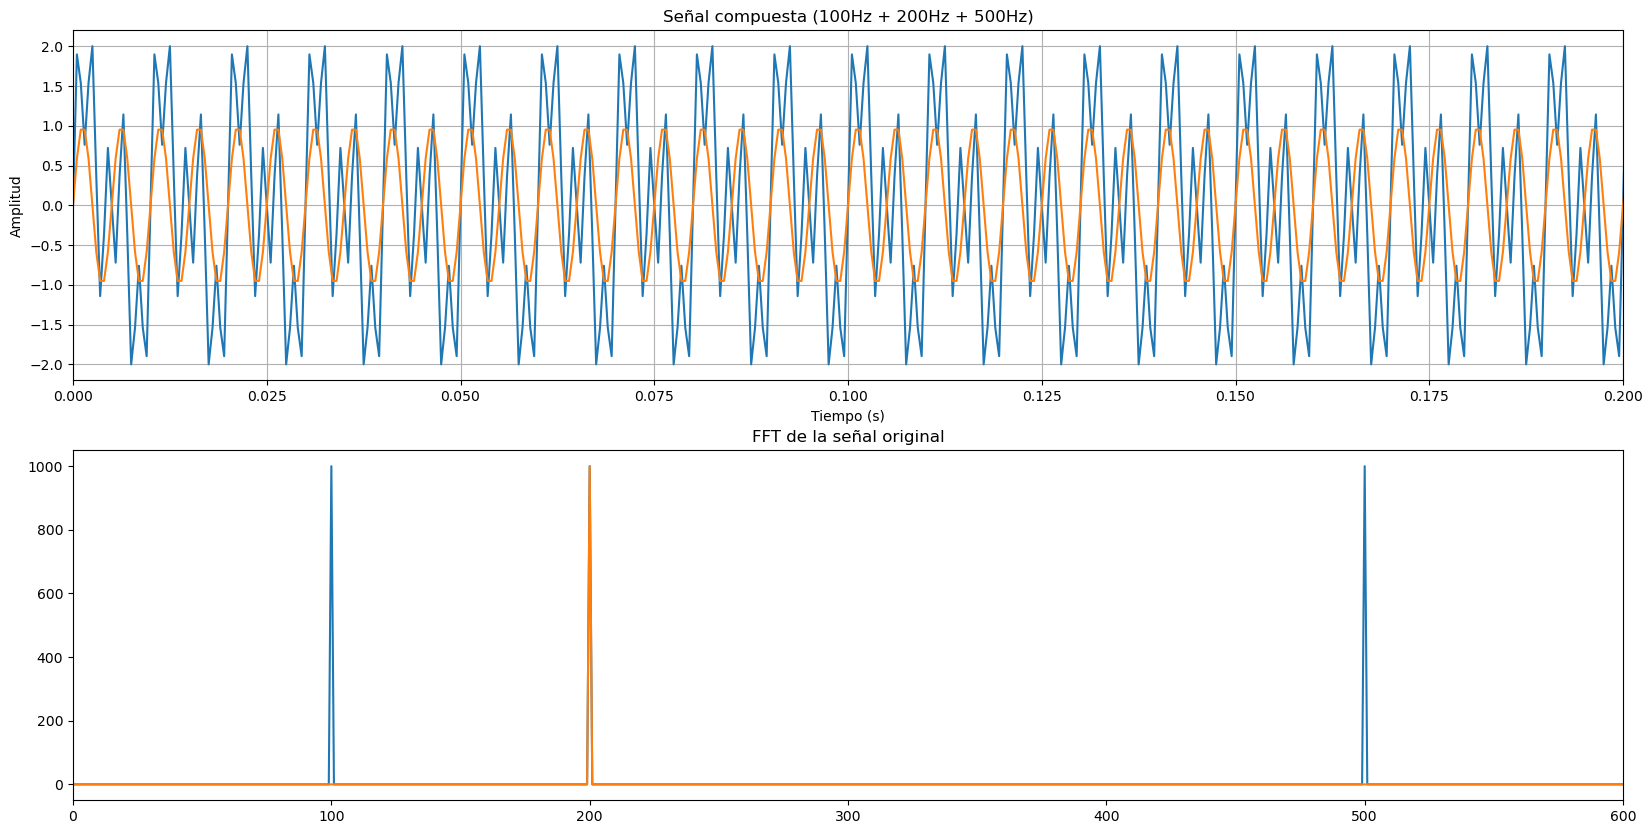

In [3]:
fs = 2000 
t = np.arange(0, 1, 1/fs) 
signal = (np.sin(2*np.pi*100*t) +  np.sin(2*np.pi*200*t) +  np.sin(2*np.pi*500*t))
signal2 = np.sin(2*np.pi*200*t)
fft_original = np.fft.fft(signal)
fft_desired = np.fft.fft(signal2)
freqs = np.fft.fftfreq(len(signal), 1/fs)
freqs2 = np.fft.fftfreq(len(signal2), 1/fs)

plt.figure(figsize=(20, 10))
plt.subplot(2,1,1);plt.plot(t, signal) ;plt.plot(t,signal2);
plt.title('Señal compuesta (100Hz + 200Hz + 500Hz)');plt.xlabel('Tiempo (s)');plt.ylabel('Amplitud');plt.xlim([0, 0.2]);plt.grid(True)

plt.subplot(2,1,2);plt.plot(freqs[:fs//2], np.abs(fft_original[:fs//2]));plt.plot(freqs2[:fs//2], np.abs(fft_desired[:fs//2]))
plt.title("FFT de la señal original")
plt.xlim(0, 600);
plt.show;

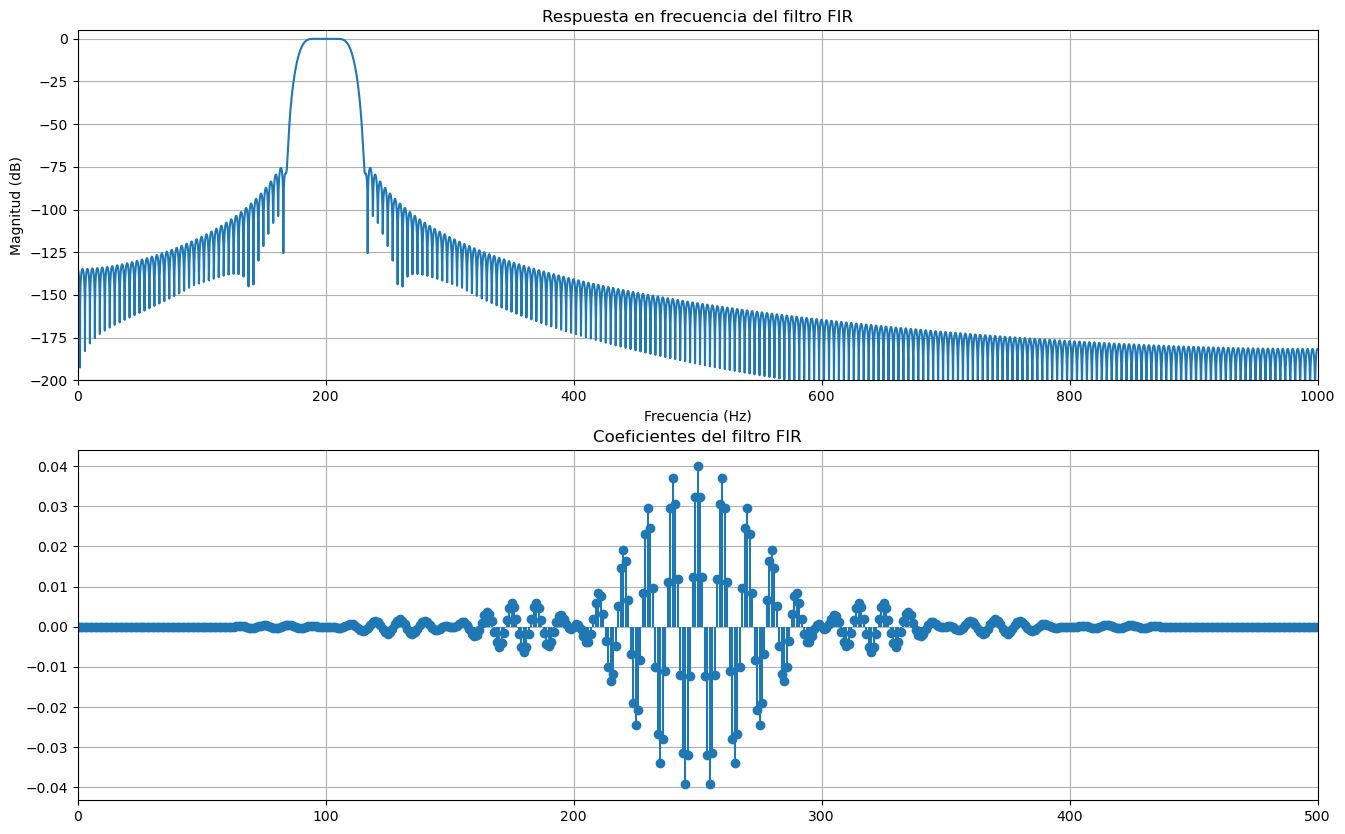

In [5]:
b = pd.read_csv('coeffs.csv', header=None).squeeze().to_numpy()
a = [1.0] 
w, h = freqz(b, worN=8000)

plt.figure(figsize=(16,10))
plt.subplot(2,1,1);plt.plot(0.5 * fs * w / np.pi, 20 * np.log10(np.abs(h)))
plt.title("Respuesta en frecuencia del filtro FIR");plt.xlabel("Frecuencia (Hz)");plt.ylabel("Magnitud (dB)");
plt.ylim(-200, 5);plt.xlim(0,1000);plt.grid()

plt.subplot(2,1,2);plt.stem(b, basefmt=" ")
plt.xlim(0,500);plt.grid();plt.title("Coeficientes del filtro FIR");

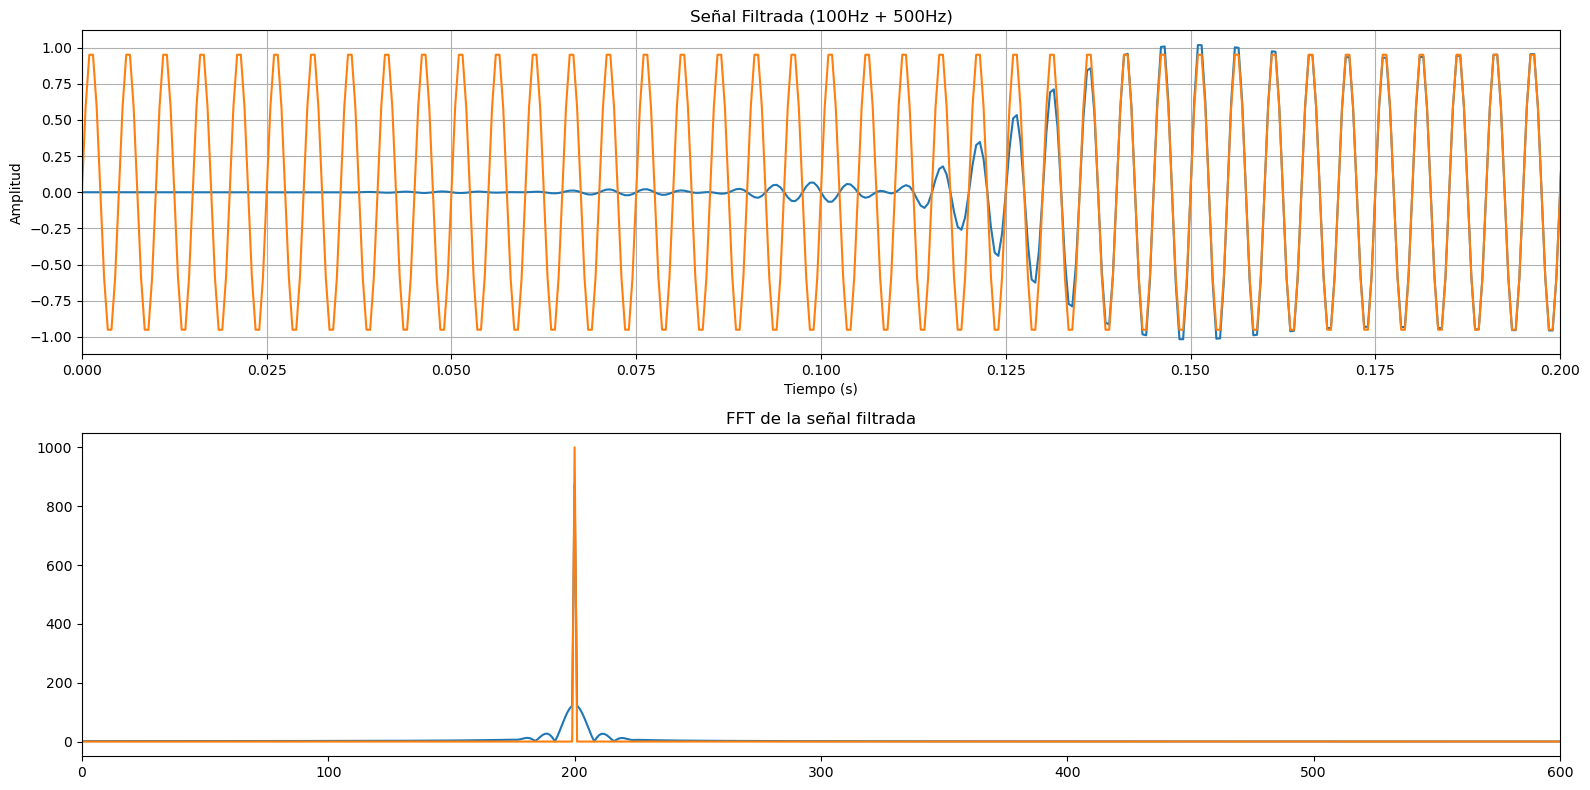

In [7]:
filtered_signal1 = lfilter(b, a, signal)
fft_filtered1 = np.fft.fft(filtered_signal1)

plt.figure(figsize=(16,8))
plt.subplot(2,1,1);plt.plot(t, filtered_signal1);plt.plot(t,signal2);
plt.title('Señal Filtrada (100Hz + 500Hz)');plt.xlabel('Tiempo (s)');plt.ylabel('Amplitud')
plt.xlim([0,0.2]);plt.grid(True);

plt.subplot(2,1,2);plt.plot(freqs[:fs//2], np.abs(fft_filtered1[:fs//2]));plt.plot(freqs2[:fs//2], np.abs(fft_desired[:fs//2]))
plt.title("FFT de la señal filtrada");plt.xlim(0, 600);plt.tight_layout();plt.show();

# 2. Diseño de filtros FIR usando SciPy

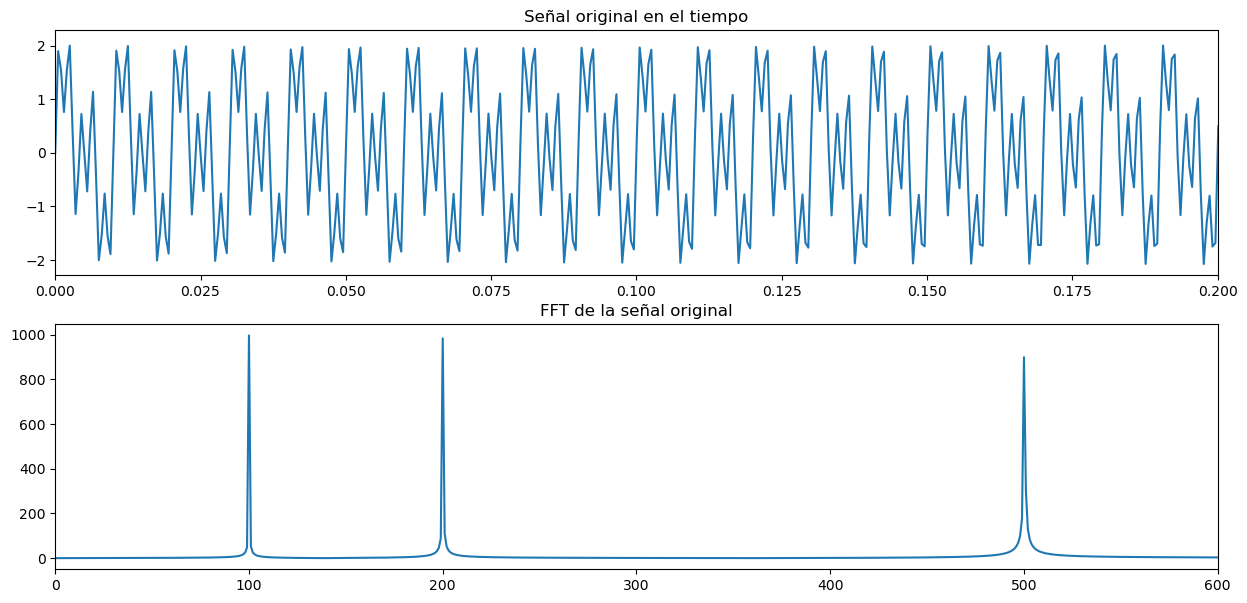

In [52]:
fs = 2000
t = np.linspace(0, 1, fs)

signal = np.sin(2 * np.pi * 100 * t) + np.sin(2 * np.pi * 200 * t) + np.sin(2 * np.pi * 500 * t)
fft_original = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(signal), 1/fs)

plt.figure(figsize=(15,7))
plt.subplot(2, 1, 1);plt.plot(t, signal)
plt.title("Señal original en el tiempo");plt.xlim([0,0.2]);

plt.subplot(2, 1, 2);plt.plot(freqs[:fs//2], np.abs(fft_original[:fs//2]))
plt.title("FFT de la señal original")
plt.xlim(0, 600);

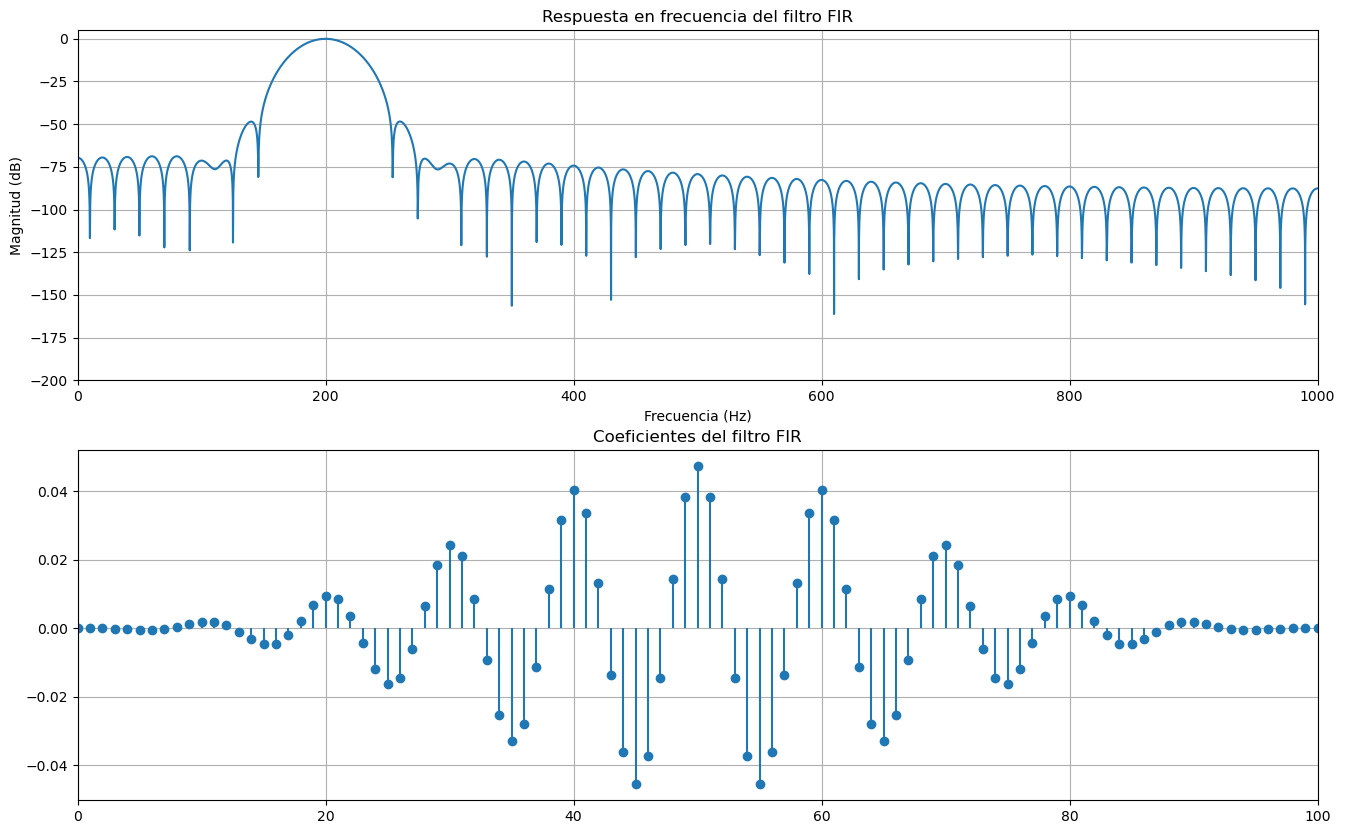

In [53]:
nyq = fs / 2
low_cutoff = 180 / nyq
high_cutoff = 220 / nyq
numtaps = 101  # Orden del filtro
ripple_db = 60  # No se usa directamente con 'firwin' pero se asocia a la ventana
fir_coeff = firwin(numtaps, [low_cutoff, high_cutoff], window='hamming', pass_zero=False)

# Respuesta en frecuencia del filtro
w, h = freqz(fir_coeff, worN=8000)

plt.figure(figsize=(16,10))
plt.subplot(2,1,1);plt.plot(0.5 * fs * w / np.pi, 20 * np.log10(np.abs(h)))
plt.title("Respuesta en frecuencia del filtro FIR");plt.xlabel("Frecuencia (Hz)");plt.ylabel("Magnitud (dB)")
plt.ylim(-200, 5);plt.xlim(0,1000);plt.grid()

plt.subplot(2, 1, 2);plt.stem(fir_coeff, basefmt=" ")
plt.xlim(0,100);plt.grid();plt.title("Coeficientes del filtro FIR");

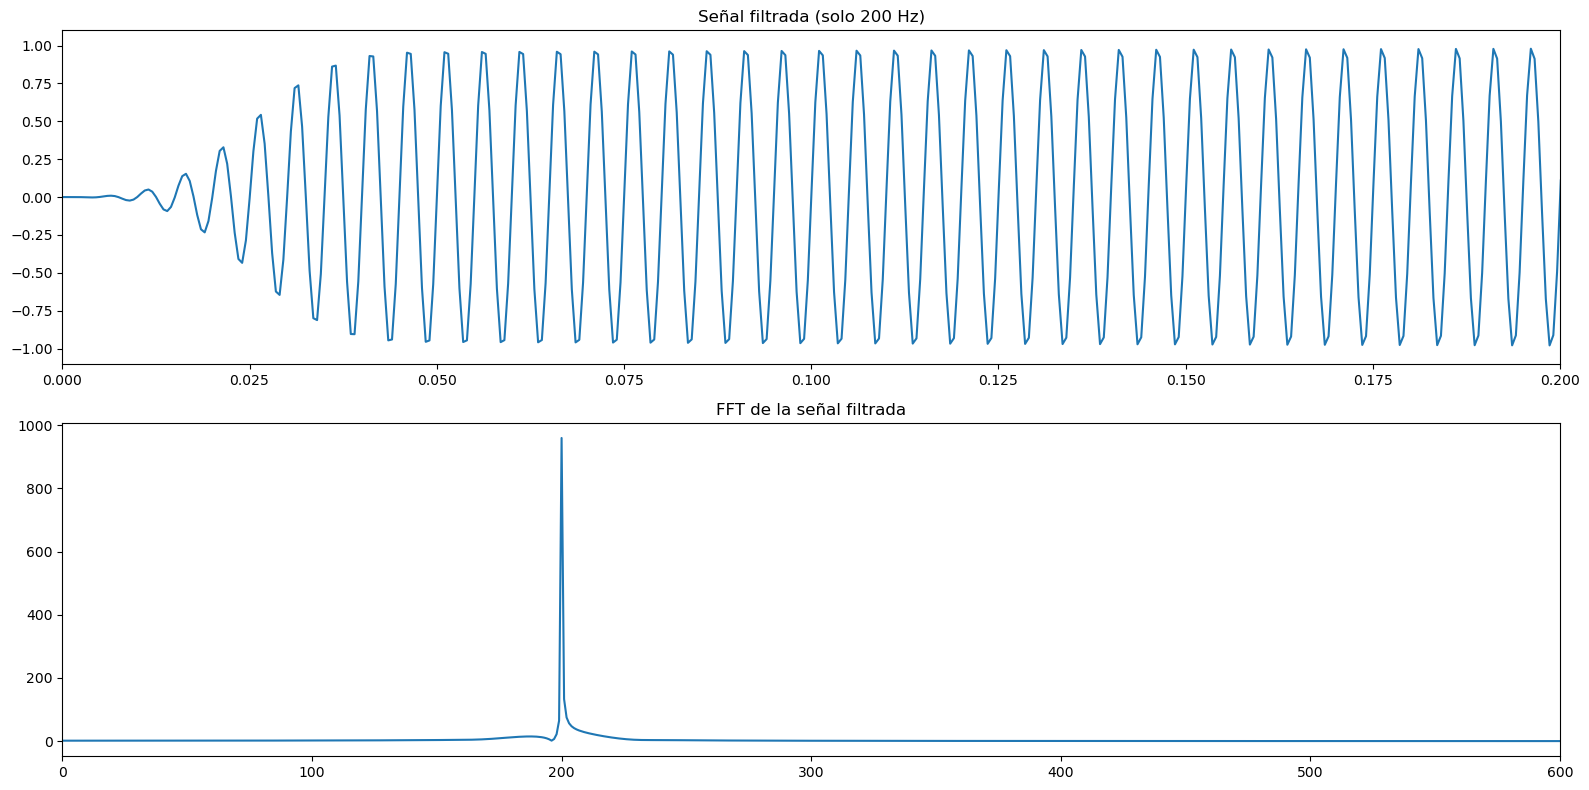

In [54]:
filtered_signal = lfilter(fir_coeff, 1.0, signal)
fft_filtered = np.fft.fft(filtered_signal)

plt.figure(figsize=(16,8))
plt.subplot(2, 1, 1);plt.plot(t, filtered_signal)
plt.title("Señal filtrada (solo 200 Hz)");plt.xlim(0,0.2);

plt.subplot(2, 1, 2);plt.plot(freqs[:fs//2], np.abs(fft_filtered[:fs//2]))
plt.title("FFT de la señal filtrada");plt.xlim(0, 600);plt.tight_layout()
plt.show()